In [1]:
import sys
print(sys.executable)
#SE NON VEDI "sam2env" NEL KERNEL LIST
#C:\Users\lore\sam2env\Scripts\activate
#pip install ipykernel
#python -m ipykernel install --user --name sam2env --display-name "Python 3.11 (sam2env)"

c:\Users\lore\sam2env\Scripts\python.exe


In [2]:
import torch
import numpy as np
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SCELTA CHECPOINT E MODEL CONFIGURATION

#checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

#checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

#checkpoint = "../checkpoints/sam2.1_hiera_base_plus.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

device = "cuda"
model = build_sam2(model_cfg, checkpoint, device=device)
predictor = SAM2ImagePredictor(model)

In [3]:
# Carica immagine
#img_name = "img/flamingo4.png" #non vede il fenicottero
#img_name = "img/bird4.png" #bene
#img_name = "img/acoustic_guitar.png" #magari aumentare k

#img_name = "img/boat.jpg" #non riconosce la barca
#img_name = "img/donuts.jpg" #bene
#img_name = "img/elephant.jpg" #bene
#img_name = "img/teddy_bear.jpg" #bene
#img_name = "img/desk.jpg" #mh, magari aumentare top_k
#img_name = "img/pizza.jpg" #bene
#img_name = "img/lunch.jpg" #bene
img_name = "img/people.jpg" #bene

image = Image.open(img_name).convert("RGB")
image = np.array(image)

In [4]:
with torch.inference_mode():
    predictor.set_image(image)

MASCHERE

In [5]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# basic mode
mask_generator_default = SAM2AutomaticMaskGenerator(model)

# low mode
mask_generator_low = SAM2AutomaticMaskGenerator(
   model,
   points_per_side=16,
   pred_iou_thresh=0.85,
   stability_score_thresh=0.90,
   box_nms_thresh=0.7,
   min_mask_region_area=500,
)

# balanced mode
mask_generator_balanced = SAM2AutomaticMaskGenerator(
   model,
   points_per_side=32,
  pred_iou_thresh=0.88,
  stability_score_thresh=0.92,
  box_nms_thresh=0.7,
  min_mask_region_area=1000,
)

# high quality mode
mask_generator_high = SAM2AutomaticMaskGenerator(
   model,
   points_per_side=64,
   pred_iou_thresh=0.92,
   stability_score_thresh=0.95,
   box_nms_thresh=0.5,
   crop_n_layers=1,
   min_mask_region_area=1500,
)

# CONFIGURAZIONE CON TUTTE LE MASCHERE
configs = {
    "default": mask_generator_default,
    "low": mask_generator_low,
    "balanced": mask_generator_balanced,
    "high": mask_generator_high,
}


PREDIZIONE MASCHERE E LE SALVO IN RESULT

In [ ]:
results = {}

for name, gen in configs.items():
    masks = gen.generate(image)
    results[name] = masks

C:\Users\lore\Desktop\UNI\TESI\sam2-main\sam2\sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\lore\Desktop\UNI\TESI\sam2-main\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


SCEGLIERE UNO DI QUESTI ORDINAMENTI

In [7]:
import math
#ORDINAMENTI COMBINATI
#Ranking completo (quello più “production-like”)
def full_sort(masks):
    return sorted(masks,key=lambda x: (x["predicted_iou"]* x["stability_score"]* math.log(x["area"] + 1)),reverse=True)

#Ranking combinato qualità + dimensione
def quality_dim_sort(masks):
    return  sorted(masks,key=lambda x: x["predicted_iou"] * math.log(x["area"] + 1), reverse=True)

#Ranking qualità + stabilità
def quality_stability_sort(masks):
    return  sorted(masks,key=lambda x: x["predicted_iou"] * x["stability_score"],reverse=True)


In [8]:
# ORDINAMENTI SINGOLI
# ordina per qualità stimata della maschera
def iou_sort(masks):
    return sorted(masks, key=lambda x: x["predicted_iou"], reverse=True)


# Ordinamento per area
def area_sort(masks):
    return sorted(masks, key=lambda x: x["area"], reverse=True)


# Ordinamento per stability score
def stability_sort(masks):
    return sorted(masks, key=lambda x: x["stability_score"], reverse=True)

In [9]:
# ORDINAMENTI SPECIFICI
# Ordinamento per bounding box size
def box_size_sort(masks):
    return sorted(masks,key=lambda x: x["bbox"][2] * x["bbox"][3],reverse=True)

# Ordinamento custom “object-centric”
def score(m):
    return (m["predicted_iou"]* m["stability_score"]* np.sqrt(m["area"]))
def object_centric_sort(masks):
    return sorted(masks, key=score, reverse=True)

In [10]:
SORT_METHODS = {
    "full": full_sort,
    "quality_dim": quality_dim_sort,
    "quality_stability": quality_stability_sort,
    "iou": iou_sort,
    "area": area_sort,
    "stability": stability_sort,
    "box_size": box_size_sort,
    "object_centric": object_centric_sort,
}

ORDINAMENTO DEL RESULT

In [11]:
ranked_results = {}

selected_sort = "full"
sort_fn = SORT_METHODS[selected_sort]

for name, masks in results.items():
    ranked_results[name] = sort_fn(masks)

SCELTA PRIME K MASCHERE + PLOT

In [12]:
top_k = 100

top_results = {
    name: masks[:min(top_k, len(masks))]
    for name, masks in ranked_results.items()
}

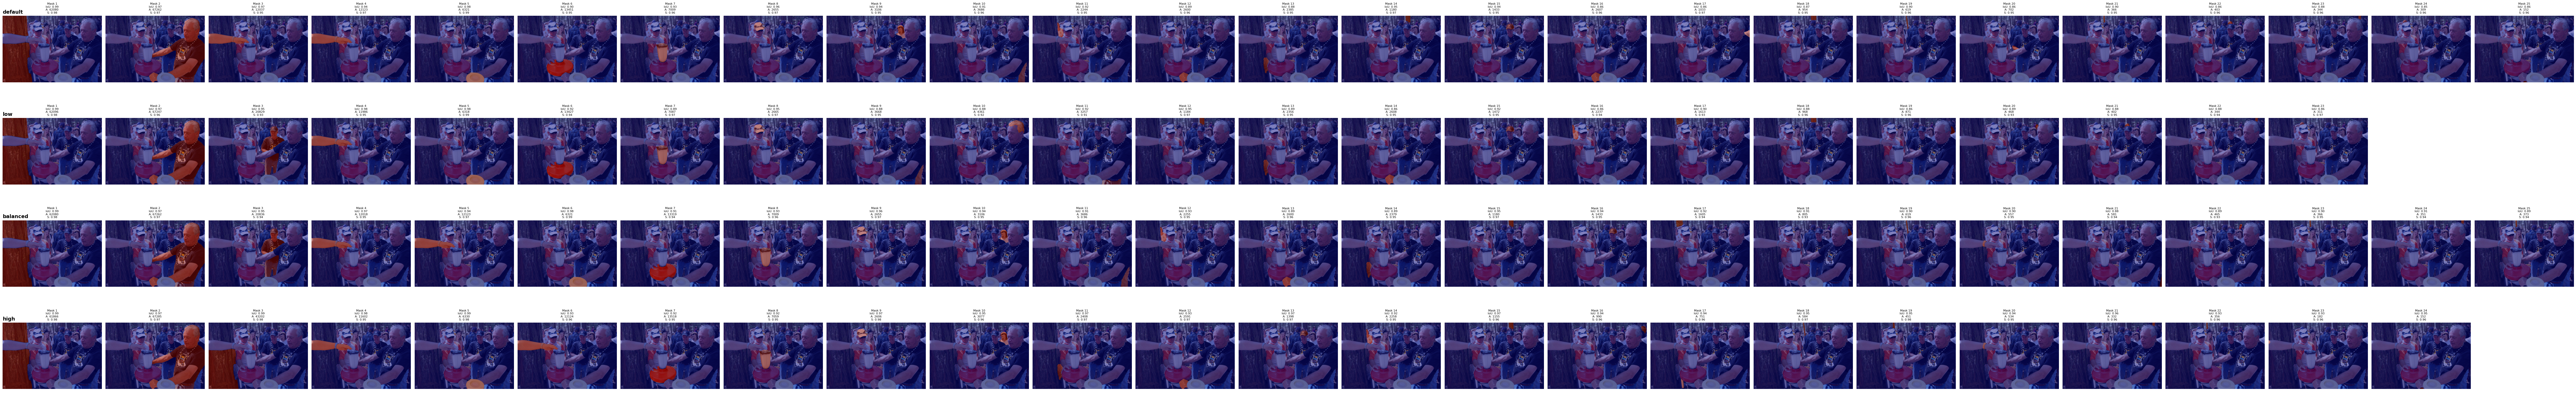

In [14]:
import matplotlib.pyplot as plt

configs = list(top_results.keys())
n_rows = len(configs)
n_cols = max(len(v) for v in top_results.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

if n_rows == 1:
    axes = [axes]

for r, config_name in enumerate(configs):

    masks = top_results[config_name]
    n = len(masks)

    for c in range(n_cols):

        ax = axes[r][c] if n_rows > 1 else axes[c]

        ax.axis("off")

        # nome configurazione a sinistra
        if c == 0:
            ax.set_title(
                config_name,
                fontsize=14,
                fontweight="bold",
                loc="left"
            )

        if c < n:

            mask = masks[c]
            seg = mask["segmentation"]

            ax.imshow(image)
            ax.imshow(seg, alpha=0.5, cmap="jet")

            ax.set_title(
                f"Mask {c+1}\n"
                f"IoU: {mask['predicted_iou']:.2f}\n"
                f"A: {mask['area']}\n"
                f"S: {mask['stability_score']:.2f}",
                fontsize=8
            )

plt.tight_layout()
plt.show()

PLOT STATISTICHE

In [15]:
import numpy as np

def compute_metrics(masks):
    areas = np.array([m["area"] for m in masks])
    ious = np.array([m["predicted_iou"] for m in masks])
    stabs = np.array([m["stability_score"] for m in masks])

    return {
        "num_masks": len(masks),
        "avg_iou": float(ious.mean()),
        "avg_stability": float(stabs.mean()),
        "small_masks_ratio": float((areas < 2000).mean()),
        "large_masks_ratio": float((areas > 20000).mean()),
    }


In [16]:
comparison_data = []

for config_name, masks in top_results.items():
    m = compute_metrics(masks)
    m["config"] = config_name
    comparison_data.append(m)

In [17]:
configs = [d["config"] for d in comparison_data]
num_masks = [d["num_masks"] for d in comparison_data]
avg_iou = [d["avg_iou"] for d in comparison_data]
avg_stability = [d["avg_stability"] for d in comparison_data]
detail_score_s = [d["small_masks_ratio"] for d in comparison_data]
detail_score_l = [d["large_masks_ratio"] for d in comparison_data]

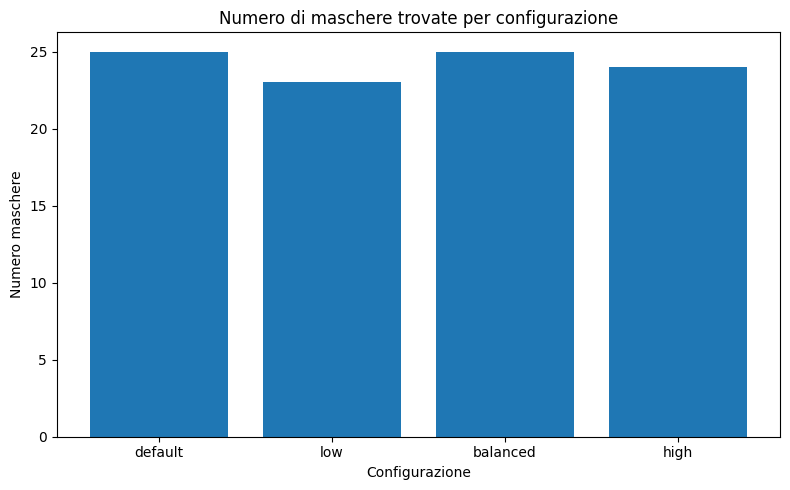

In [18]:
import matplotlib.pyplot as plt
import numpy as np

configs = [d["config"] for d in comparison_data]
num_masks = [d["num_masks"] for d in comparison_data]

plt.figure(figsize=(8,5))
plt.bar(configs, num_masks)
plt.title("Numero di maschere trovate per configurazione")
plt.ylabel("Numero maschere")
plt.xlabel("Configurazione")
plt.tight_layout()
plt.show()

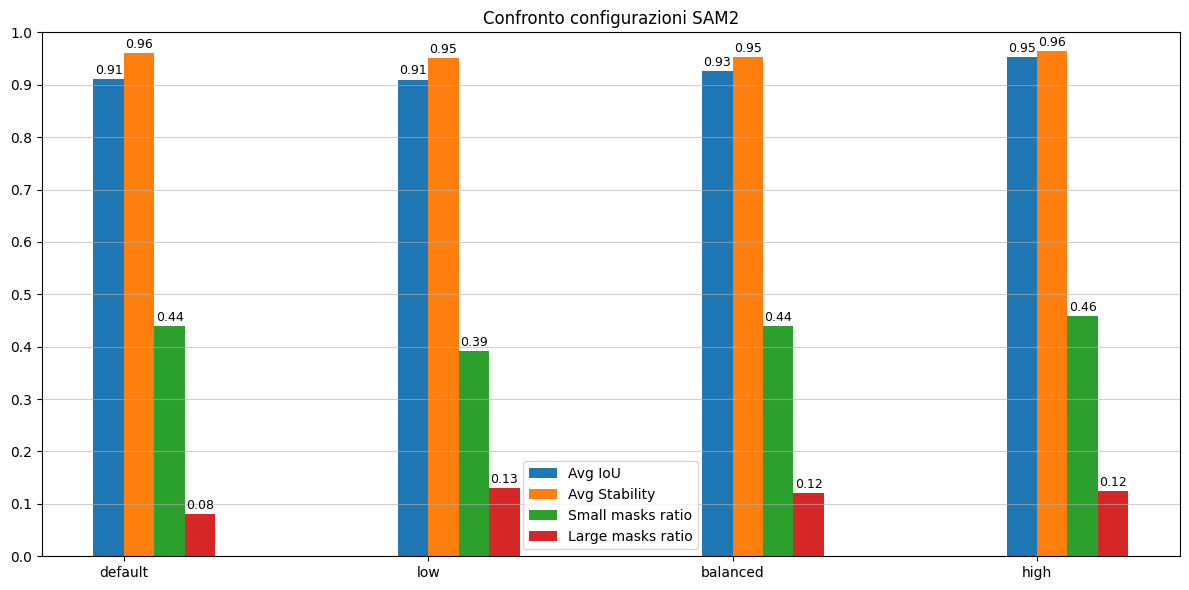

In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(configs))
width = 0.1

plt.figure(figsize=(12, 6))

plt.bar(x - 0.5*width, avg_iou, width, label="Avg IoU")
plt.bar(x + 0.5*width, avg_stability, width, label="Avg Stability")
plt.bar(x + 1.5*width, detail_score_s, width, label="Small masks ratio")
plt.bar(x + 2.5*width, detail_score_l, width, label="Large masks ratio")

for i, v in enumerate(avg_iou):
    plt.text(x[i] - 0.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(avg_stability):
    plt.text(x[i] + 0.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(detail_score_s):
    plt.text(x[i] + 1.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(detail_score_l):
    plt.text(x[i] + 2.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

plt.xticks(x, configs)
plt.title("Confronto configurazioni SAM2")
plt.grid(axis="y", linestyle="-", alpha=0.6)
plt.legend()
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.tight_layout()
plt.show()